In [16]:
import pandas as pd
import numpy as np

Ue = 10 # peak voltage

def calcBode(df):
    df['A'] = 20 * np.log10(df['Ua'] / Ue)
    return df

df_I = calcBode(pd.read_csv("./data/1d_Abs.csv"))

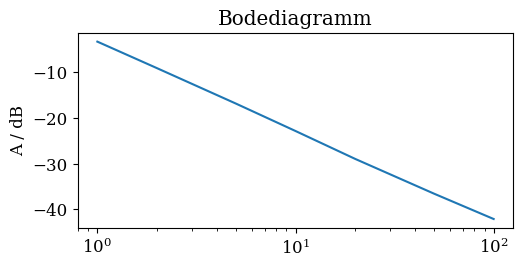

In [18]:
import matplotlib
from matplotlib import pyplot as plt

cm = 1/2.54

font = {'family' : 'serif',
        'weight' : 'normal',
        'size' : 12}
matplotlib.rc('font', **font)

def plot_bode(df, title="Bodediagramm"):
    fig, ax_abs = plt.subplots(nrows=1, ncols=1, figsize=(13*cm, 6.5*cm), constrained_layout=True)
    ax_abs.set_title(title)
    ax_abs.set_ylabel("A / dB")
    ax_abs.set_xscale('log')
    ax_abs.plot(df['f'], df['A'])

    return fig

fig_I = plot_bode(df_I, title="Bodediagramm")
fig_I.savefig("./latex/images/14_bode_1d_Abs.png")

In [ ]:
fmt = {
    'f': '{:.0e}',
    'Ua': '{:.2f}',
	'A': '{:.2f}',
}
latex_I = df_I.style.format(fmt).hide().to_latex()
with open("./latex/images/14_bode_tab.tex", "w") as f:
    f.write(latex_I)